# GSR Audio Analysis

This notebook explains how to transform a time series such as a **GSR (Galvanic Skin Response)** signal into an audio file.

The goal is **not** to create something pleasant to listen to. In fact, it will probably sound like noise. However, converting the signal into a WAV file allows us to use powerful audio-analysis tools. These tools can extract additional features from the data. We can then:

* visualise these features,
* compare recordings,
* or use them as inputs for dimensionality-reduction methods such as UMAP.

So we are not really *making music* — we are **translating formats**.


### Important assumptions

To make this translation possible, we need two adjustments.

**Time can be stretched or compressed**

The original recording might last 10–20 minutes. For analysis, we may want it to become, for example, *30 seconds*. Both are valid — they simply change the resolution at which we observe patterns.

**Values must be normalised**

GSR values often sit in ranges such as 240–540 (or other units). Audio signals, however, typically expect values between –1 and +1. Therefore, we rescale the data into this range. This step is called normalisation.



### What this notebook does

We proceed step by step:

1. Load a GSR (EDA) recording from a table file (CSV or TSV).
2. Visualise the raw signal.
3. Convert the signal into a WAV file (again: not for listening).
4. Extract common audio features such as
5. Saves the results back into the table



### Why WAV?

WAV is a simple and widely supported format for 1-dimensional time signals.
Many analysis libraries are designed to read audio files, so using WAV lets us plug directly into them.


### What you need

* A data file containing a column called **`GSR`**
  (or change the column name in the notebook).
* Python packages:
  `numpy`, `pandas`, `matplotlib`, `librosa`, `soundfile`

If you don’t have them installed:

```bash
pip install numpy pandas matplotlib librosa soundfile
```

# Chapter 1 — Setup

Edit the paths and column name below.  
If your file is **tab-separated** use `sep="\t"`. If it’s comma-separated, use `sep=","`.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# -----------------------------
# 1) PATHS / FILE SETTINGS
# -----------------------------
DATA_PATH = Path(r"assets\010RC14X.CSV")   # <-- change to your file
SEP = "\t"                       # "\t" for TSV, "," for CSV
GSR_COLUMN = "GSR"                # <-- change if your column has a different name

# -----------------------------
# 2) WAV EXPORT SETTINGS
# -----------------------------
WAV_PATH = Path(r"assets\gsr.wav")        # output file
AUDIO_SR = 44100                  # WAV sample rate (Hz)

# Export mode: fixed-length WAV (stretch)

TARGET_DURATION_SEC = 30.0       

# Normalisation options
REMOVE_MEAN = True                # subtract average (recommended for drift)
CLIP = 0.999                      # avoid int16 clipping

# -----------------------------
# 2) CSV EXPORT SETTINGS
# -----------------------------
       
  # output file for the GSR features

## Chapter 2 — Load and inspect the data


In [2]:
df = pd.read_csv(DATA_PATH, sep=SEP)
df.head()

,Count,Date,Time,Lat,Long,Speed,Altitude,GSR
0,0,27/5/2018,15:16:37,51.537693,-0.029900,4.70,0.0,565
1,1,27/5/2018,15:16:37,51.537693,-0.029900,4.70,67.6,563
2,2,27/5/2018,15:16:38,51.537708,-0.029881,3.11,67.6,563
3,3,27/5/2018,15:16:39,51.537716,-0.029865,3.22,67.6,559
4,4,27/5/2018,15:16:40,51.537689,-0.029866,6.67,67.6,557


In [3]:
print("Columns:", list(df.columns))
print("Rows:", len(df))

Columns: ['Count', 'Date', 'Time', 'Lat', 'Long', 'Speed', 'Altitude', 'GSR']
Rows: 4100


# Chapter 3 — Plot the raw GSR signal

This is a sanity check:
- Do you see the expected overall drift (tonic level)?
- Do you see peaks (phasic responses)?
- Are there missing values (NaNs)?


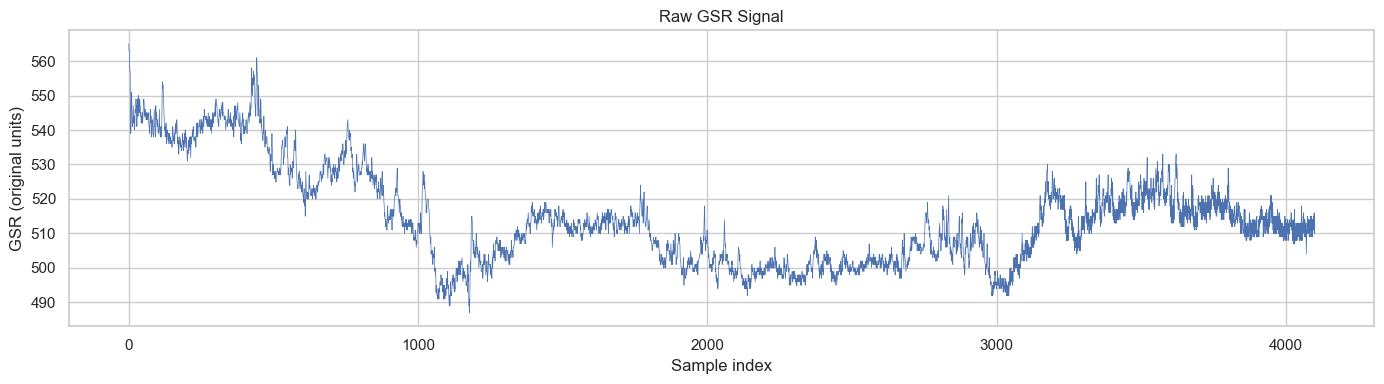

Min / Max: 487.0 565.0


In [4]:
# ------------------------------------------------
# Convert column to numeric array
# ------------------------------------------------
gsr = df[GSR_COLUMN].astype(float).to_numpy()

# Optional: handle missing values (forward/back fill)
if np.isnan(gsr).any():
    gsr = pd.Series(gsr).fillna(method="ffill").fillna(method="bfill").to_numpy()

# ------------------------------------------------
# Seaborn style
# ------------------------------------------------
sns.set_theme(style="whitegrid")

# ------------------------------------------------
# Plot
# ------------------------------------------------
plt.figure(figsize=(14, 4))

sns.lineplot(
    x=np.arange(len(gsr)),
    y=gsr,
    linewidth=0.5
)

plt.title("Raw GSR Signal")
plt.xlabel("Sample index")
plt.ylabel("GSR (original units)")

plt.tight_layout()
plt.show()

print("Min / Max:", float(np.min(gsr)), float(np.max(gsr)))


# Chapter 4 — Convert GSR to an audio-safe signal

Audio PCM samples must live in **[-1, +1]** before writing to WAV.

We do:
1. (Optional) subtract the mean (removes offset / drift baseline)
2. normalise by the maximum absolute value
3. clamp to a safe range (`CLIP`)


(4100,)


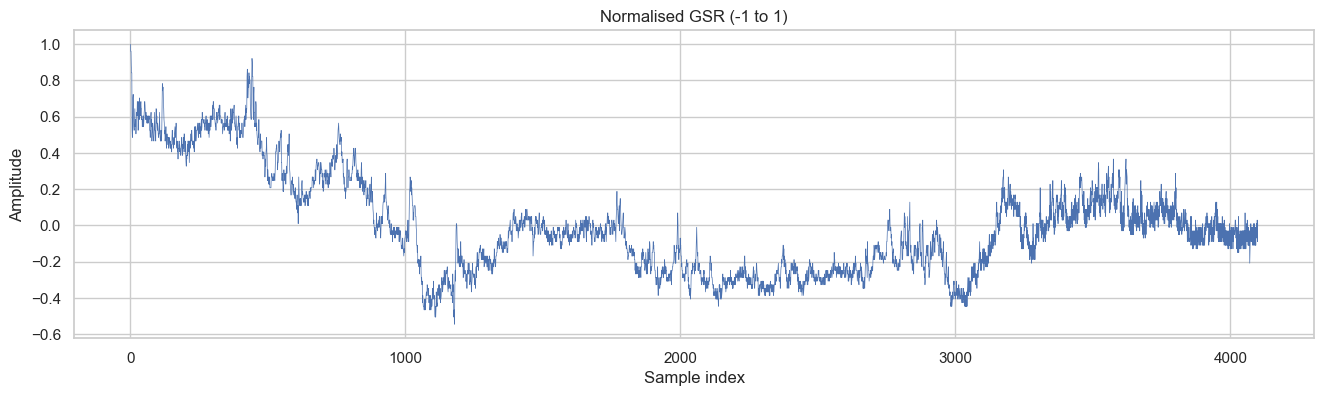

Normalised min/max: -0.5443605246382972 0.999


In [ ]:
def normalize_to_audio(x: np.ndarray, remove_mean: bool = True, clip: float = 0.999) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if x.size < 2:
        raise ValueError("Signal is empty or too short.")

    if remove_mean:
        x = x - np.mean(x)

    max_abs = np.max(np.abs(x))
    if max_abs == 0:
        return np.zeros_like(x)

    y = x / max_abs
    y = np.clip(y, -clip, clip)
    return y


normalized_gsr = normalize_to_audio(gsr, remove_mean=REMOVE_MEAN, clip=CLIP)


plt.figure(figsize=(16,4))

sns.lineplot(
    x=np.arange(len(normalized_gsr)),
    y=normalized_gsr,
    linewidth=0.5
)

plt.title("Normalised GSR (-1 to 1)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()

print("Normalised min/max:", float(np.min(normalized_gsr)), float(np.max(normalized_gsr)))


# Chapter 5 — Resample to a chosen WAV length

GSR is typically recorded at **4–32 Hz**, while WAV audio commonly uses **44,100 Hz**.

We need to **upsample** (and optionally time-stretch) the signal.
- The whole signal is stretched/compressed to `TARGET_DURATION_SEC`
- Useful when you want **fixed-length** files for batch processing




In [6]:
def resample_linear(x: np.ndarray, target_len: int) -> np.ndarray:
    """Linear interpolation resampling to exactly target_len samples."""
    x = np.asarray(x, dtype=float)
    n = x.size
    if n == 0:
        raise ValueError("Empty signal.")
    if target_len <= 1:
        return np.array([x[0]], dtype=float)
    if n == 1:
        return np.full((target_len,), float(x[0]), dtype=float)

    # positions in original index space
    pos = np.linspace(0, n - 1, target_len)
    left = np.floor(pos).astype(int)
    right = np.minimum(left + 1, n - 1)
    t = pos - left
    return (1.0 - t) * x[left] + t * x[right]


target_len = int(round(AUDIO_SR * TARGET_DURATION_SEC))
audio = resample_linear(normalized_gsr, target_len)
wav_duration = TARGET_DURATION_SEC

print("WAV duration (sec):", wav_duration)
print("Audio samples:", len(audio))


WAV duration (sec): 30.0
Audio samples: 1323000


# Chapter 6 — Write the WAV file (PCM 16-bit)

We write **mono**, **16-bit** PCM — the most compatible WAV type.


In [7]:
import wave

def write_wav_16bit_mono(path: Path, samples: np.ndarray, sample_rate: int) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    samples = np.asarray(samples, dtype=float)
    samples = np.clip(samples, -1.0, 1.0)

    # Convert float [-1..1] to int16
    int16 = (samples * 32767.0).round().astype(np.int16)

    with wave.open(str(path), "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)          # 2 bytes = 16-bit
        wf.setframerate(sample_rate)
        wf.writeframes(int16.tobytes())

write_wav_16bit_mono(WAV_PATH, audio, AUDIO_SR)
print("Wrote:", WAV_PATH.resolve())


Wrote: C:\Users\VincentNowak\Dropbox\UCL RC15 Skills 2025\PervasiveUrbanism_25-26\Extra 04 - GSR to UMAP\assets\gsr.wav


# Chapter 7 — Load the WAV with `librosa` and extract features

Now we treat the WAV as an input to audio toolkits.

**Important:** the frequency axis is now a *mathematical artefact* of our conversion.  
Use these features as **shape descriptors** of the GSR dynamics, not literal “pitch”.


In [8]:
import librosa
import librosa.display

y, sr = librosa.load(str(WAV_PATH), sr=None, mono=True)
print("Loaded WAV:", len(y), "samples at", sr, "Hz")


Loaded WAV: 1323000 samples at 44100 Hz


### Choose analysis length (optional)

If you only want the first N seconds, set `analysis_sec`.  
If you want the full recording, set `analysis_sec=None`.


In [10]:
analysis_sec = None  # e.g. 20.0 or None

if analysis_sec is None:
    y_clip = y
else:
    n = int(round(float(analysis_sec) * sr))
    y_clip = y[:n]

print("Analysing seconds:", len(y_clip) / sr)


Analysing seconds: 30.0


### Extract a starter set of features

We compute a first group of measurements that describe how the signal behaves over time. Although these are commonly called audio features, they are simply different mathematical views of a changing curve.


**STFT power spectrum (Short-Time Fourier Transform)**

The signal is divided into many small time windows. Within each window we examine the rate and intensity of change. The result is often displayed as a spectrogram.
For GSR, this does not represent musical pitch. It indicates the speed of variation.
Lower frequencies correspond to slow baseline drift. Higher frequencies correspond to quicker responses.



**RMS energy (Root Mean Square)**

This describes the strength of activity within each time window.
In sound, RMS relates to perceived loudness. For GSR it can be read as the level of activation.
Higher values indicate stronger or more frequent changes. Lower values indicate relative stability.
It is one of the most reliable and interpretable measures.



**Spectral centroid**

The centroid is the balance point of activity across frequencies.
In musical contexts it is associated with brightness. For GSR it reflects whether behaviour is dominated by slower or faster variations.
Higher values suggest faster dynamics. Lower values indicate slower movement.



**Spectral bandwidth**

Bandwidth measures how widely activity is distributed.
A small bandwidth suggests concentrated behaviour. A large bandwidth suggests a mixture of slow and fast processes occurring together.
This can help differentiate between stable and complex states.



**Spectral flatness**

Flatness compares structured patterns with noise-like behaviour.
Lower values indicate more organised or dominant tendencies. Higher values suggest randomness or dispersion.
It can be useful for distinguishing clear responses from diffuse activity.



**MFCCs (Mel Frequency Cepstral Coefficients)**

MFCCs provide a compact description of the spectral shape. Instead of storing many individual frequency measurements, the information is compressed into a small set of coefficients for each window.
They are widely used in speech processing and machine learning. For this workflow, they are particularly valuable as inputs for clustering and dimensionality reduction. Individual coefficients are less intuitive to interpret, but together they describe characteristic patterns.



In [44]:
# Windowing settings (time windows for analysis)
hop_length = 1024
n_fft = 4096

# STFT power spectrum (spectrogram-like representation)
S = np.abs(librosa.stft(y_clip, n_fft=n_fft, hop_length=hop_length))**2

# RMS energy (local activity)
rms = librosa.feature.rms(S=S, frame_length=n_fft)[0]

# Shape descriptors from the spectrum
centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)[0]
flatness = librosa.feature.spectral_flatness(S=np.sqrt(S))[0]

# MFCCs (compact multi-band descriptors)
mfcc = librosa.feature.mfcc(
    y=y_clip,
    sr=sr,
    n_mfcc=13,
    n_fft=n_fft,
    hop_length=hop_length
)

# Time axis for frame-based features
t = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

# Table of frame-based features
features_df = pd.DataFrame({
    "time_audio": t,
    "rms": rms,
    "centroid_hz": centroid,
    "bandwidth_hz": bandwidth,
    "flatness": flatness,
})

print(features_df.shape)
features_df.head()



(1292, 5)


,time_audio,rms,centroid_hz,bandwidth_hz,flatness
0,0.00000,315.740906,23.251970,271.015535,1.086246e-03
1,0.02322,671.694031,5.819662,100.500465,1.486462e-04
2,0.04644,487.950592,2.200192,5.360139,6.923137e-10
3,0.06966,408.932404,2.573230,5.129722,3.176806e-10
4,0.09288,373.852051,2.107645,4.507587,1.423028e-10



> **Important**
>The table containing the extracted features has fewer rows than the original input table. This is expected. Audio analysis divides the signal into short time frames. And features are calculated once per frame, not once per original sample. As a result, the resolution changes.


Before we can combine both tables into one CSV file, we need to align them.
This means we resample or interpolate the feature values so that we get one feature value for every row in the original table.

After alignment, both tables will have the same number of rows, and we can merge them into one combined dataset.

In [49]:
# number of original samples
N = len(df)

# if the original table has no time column, create one
if "time_audio" not in df.columns:
    df_time = np.linspace(0.0, TARGET_DURATION_SEC, num=N, endpoint=False)
else:
    df_time = df["time_audio"].to_numpy()

# time axis of audio frames
t_frames = features_df["time_audio"].to_numpy()

# helper: interpolate any feature column to original length
def interp_to_samples(col):
    return np.interp(df_time, t_frames, features_df[col].to_numpy())

# build new dataframe (copy to avoid touching original)
df_extended = df.copy()

df_extended["normalised_gsr"] = normalized_gsr
df_extended["time_audio"] = interp_to_samples("time_audio") 
df_extended["rms"] = interp_to_samples("rms")
df_extended["centroid_hz"] = interp_to_samples("centroid_hz")
df_extended["bandwidth_hz"] = interp_to_samples("bandwidth_hz")
df_extended["flatness"] = interp_to_samples("flatness")

df_extended.head()

,Count,Date,Time,Lat,Long,Speed,Altitude,GSR,normalised_gsr,time_audio,rms,centroid_hz,bandwidth_hz,flatness
0,0,27/5/2018,15:16:37,51.537693,-0.029900,4.70,0.0,565,0.999000,0.000000,315.740906,23.251970,271.015535,0.001086
1,1,27/5/2018,15:16:37,51.537693,-0.029900,4.70,67.6,563,0.960401,0.007317,427.908871,17.758700,217.282819,0.000791
2,2,27/5/2018,15:16:38,51.537708,-0.029881,3.11,67.6,563,0.960401,0.014634,540.076836,12.265430,163.550102,0.000495
3,3,27/5/2018,15:16:39,51.537716,-0.029865,3.22,67.6,559,0.881203,0.021951,652.244801,6.772161,109.817386,0.000200
4,4,27/5/2018,15:16:40,51.537689,-0.029866,6.67,67.6,557,0.841604,0.029268,623.832506,4.876862,75.718296,0.000110


# Chapter 9 — Export features

In [50]:
OUT_PATH = Path("assets/GSR_Analysis.csv")
df_extended.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)


Saved: assets\GSR_Analysis.csv


# Chapter 8 — Visualise features

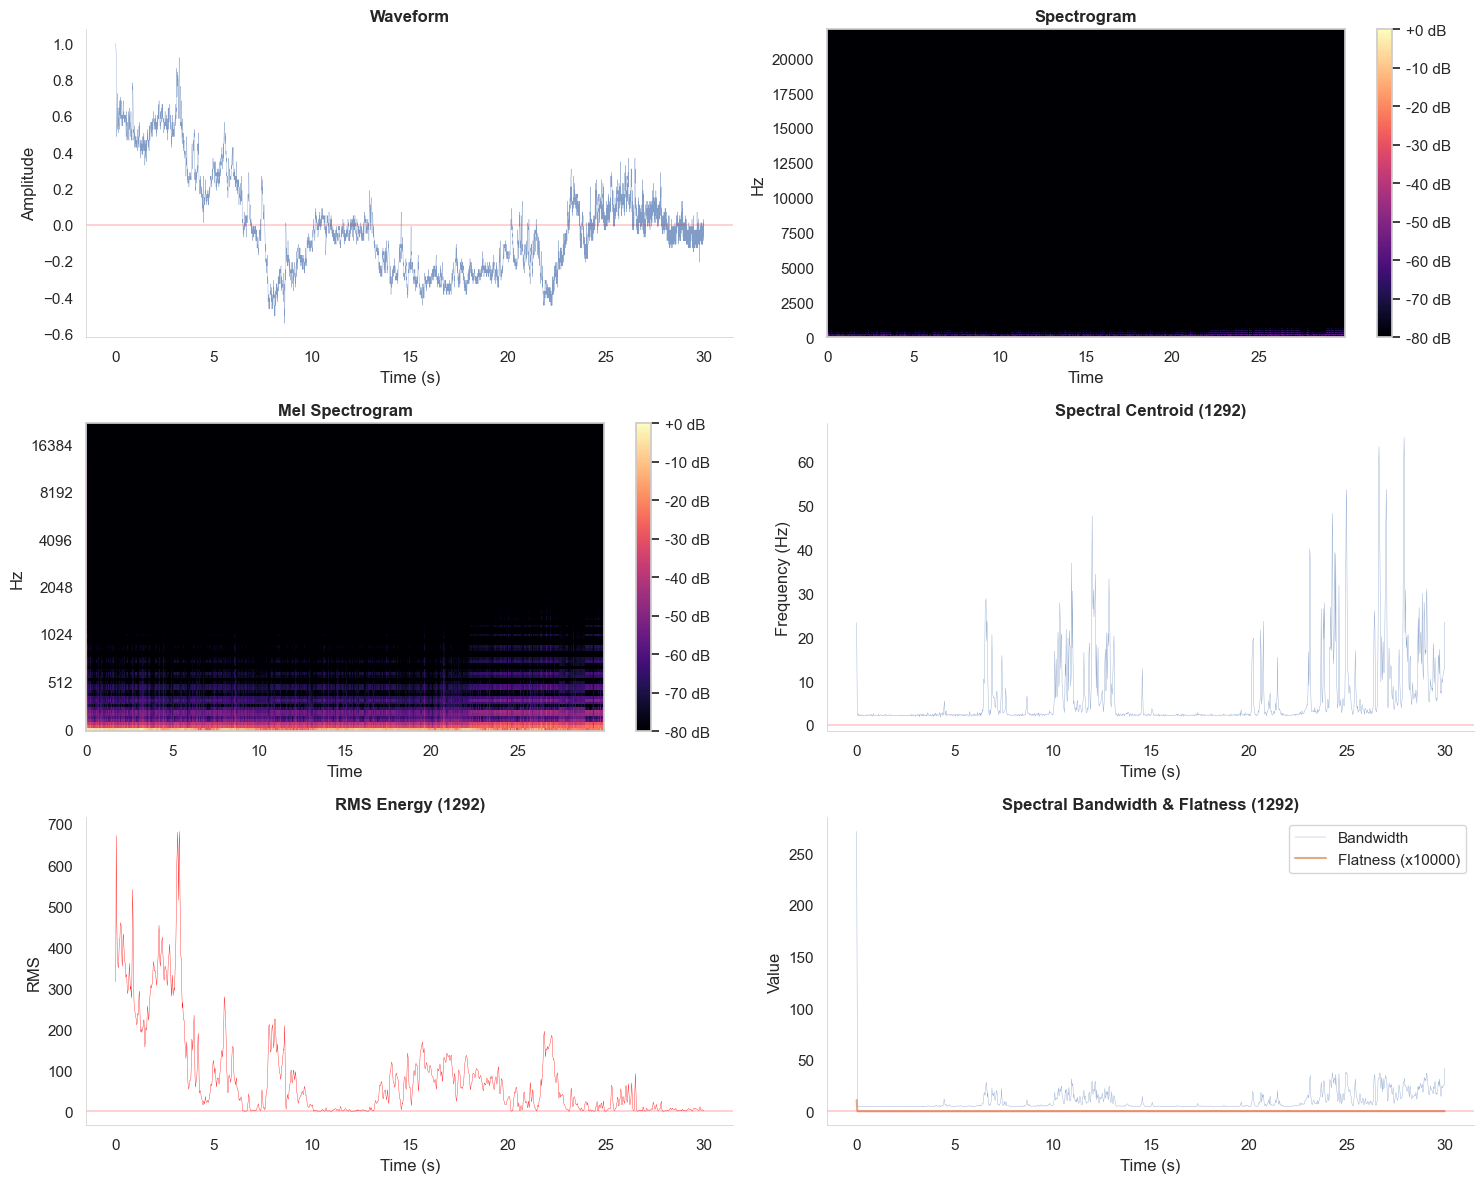

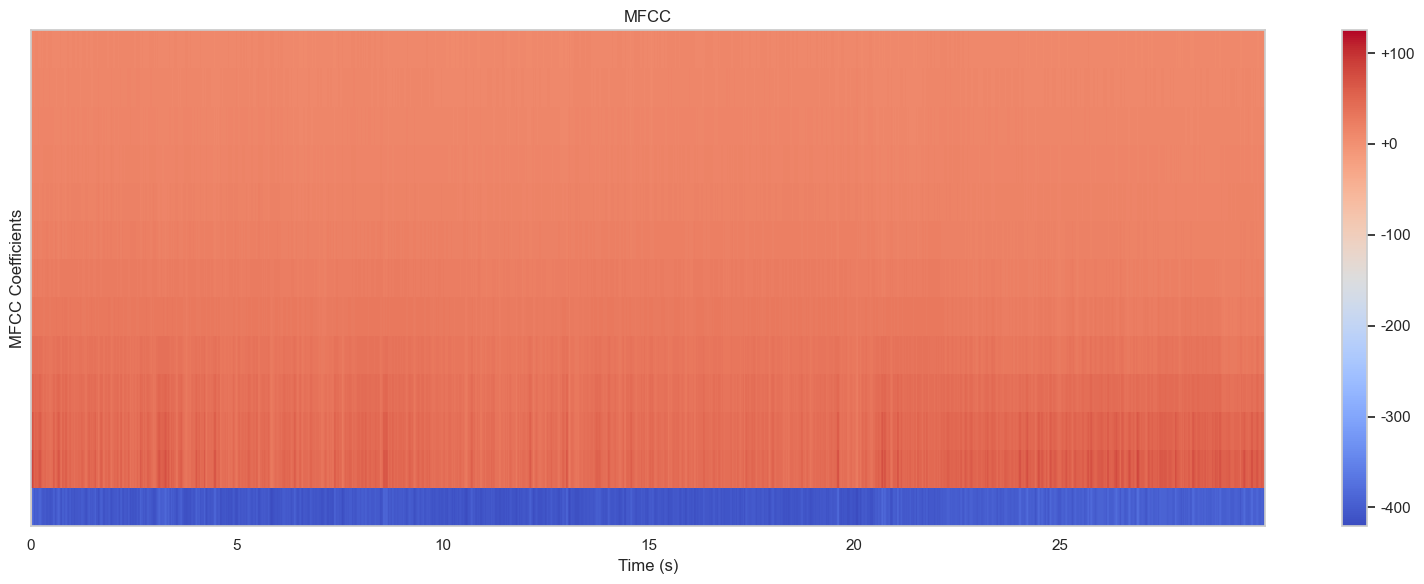

In [52]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Create a figure with multiple subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1. Waveform
axes[0, 0].plot(np.linspace(0, len(y_clip)/sr, len(y_clip)), y_clip,linewidth=0.25,alpha=0.7)
axes[0, 0].set_title('Waveform',fontweight='bold')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].spines['left'].set_linewidth(0.5)
axes[0, 0].spines['bottom'].set_linewidth(0.5)
axes[0, 0].axhline(0, color='red', linewidth=0.25)
axes[0, 0].grid(False)


# 2. Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(y_clip, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
img = librosa.display.specshow(D, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', ax=axes[0, 1])
axes[0, 1].set_title('Spectrogram',fontweight='bold')
fig.colorbar(img, ax=axes[0, 1], format='%+2.0f dB')

# 3. Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y_clip, sr=sr, n_fft=n_fft, hop_length=hop_length)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=axes[1, 0])
axes[1, 0].set_title('Mel Spectrogram',fontweight='bold')
fig.colorbar(img2, ax=axes[1, 0], format='%+2.0f dB')

# 4. Spectral Features over time
axes[1, 1].plot(features_df["time_audio"], features_df["centroid_hz"], label='Centroid', alpha=0.7,linewidth=0.25)
axes[1, 1].set_title('Spectral Centroid ('+ str(len(features_df["centroid_hz"])) + ')',fontweight='bold')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Frequency (Hz)')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].spines['left'].set_linewidth(0.5)
axes[1, 1].spines['bottom'].set_linewidth(0.5)
axes[1, 1].axhline(0, color='red', linewidth=0.25)
axes[1, 1].grid(False)

# 5. RMS Energy
axes[2, 0].plot(features_df["time_audio"], features_df["rms"], color='red', linewidth=0.25)
axes[2, 0].set_title('RMS Energy ('+ str(len(features_df["rms"])) + ')',fontweight='bold')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('RMS')
axes[2, 0].spines['top'].set_visible(False)
axes[2, 0].spines['right'].set_visible(False)
axes[2, 0].spines['left'].set_linewidth(0.5)
axes[2, 0].spines['bottom'].set_linewidth(0.5)
axes[2, 0].axhline(0, color='red', linewidth=0.25)
axes[2, 0].grid(False)

# 6. Multiple spectral features
axes[2, 1].plot(features_df["time_audio"], features_df["bandwidth_hz"], label='Bandwidth', alpha=0.7, linewidth=0.25)
axes[2, 1].plot(features_df["time_audio"], features_df["flatness"]*10000, label='Flatness (x10000)', alpha=0.7)
axes[2, 1].set_title('Spectral Bandwidth & Flatness ('+ str(len(features_df["bandwidth_hz"])) + ')',fontweight='bold')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Value')
axes[2, 1].legend()
axes[2, 1].spines['top'].set_visible(False)
axes[2, 1].spines['right'].set_visible(False)
axes[2, 1].spines['left'].set_linewidth(0.5)
axes[2, 1].spines['bottom'].set_linewidth(0.5)
axes[2, 1].axhline(0, color='red', linewidth=0.25)
axes[2, 1].grid(False)

plt.tight_layout()
plt.show()

# Additional: MFCC visualization
plt.figure(figsize=(16, 6))
librosa.display.specshow(mfcc, sr=sr, hop_length=hop_length, x_axis='time')
plt.colorbar(format='%+2.0f')
plt.title('MFCC')
plt.ylabel('MFCC Coefficients')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()
